# Rock-Paper-Scissors (RPS) — entrega

Notebook de la entrega: corre los experimentos en Rock-Paper-Scissors con FP y RM (implementaciones del equipo, en `agents/`). Persiste `history` dicts en `data/rps/`, guarda figuras en `images/rps/`, y registra el progreso en `logs/rps/RPS.log`.

Las gráficas usan los helpers de `utils.plots` (compartidos por todos los notebooks del equipo). Cap visual: 1000 iter; el history completo (5000 iter) queda en cada `.pkl` por si después se quiere otra vista.

Se evalúan tres enfrentamientos:

- FictitiousPlay vs FictitiousPlay
- RegretMatching vs RegretMatching
- FictitiousPlay vs RegretMatching

## Setup

In [2]:
import sys
sys.path.append('..')

%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

# Juego y agentes del equipo
from games.rps import RPS
from agents.fictitiousplay import FictitiousPlay
from agents.regretmatching import RegretMatching
from agents.random_agent import RandomAgent

# Infraestructura compartida (utils/)
from utils.logger import get_logger
from utils.storage import cached, savefig
from utils.plots import (
    plot_policy_evolution,
    plot_distance_to_nash,
    plot_cumulative_average_reward,
    plot_cumulative_regret,
    plot_average_positive_regret,
    plot_instantaneous_vs_average_policy,
    plot_simplex_pairs,
)

# Helper para ejecutar y cachear corridas (importado desde utils/experiments.py)
from utils import experiments as exp

log = get_logger(notebook_name='RPS2', game='rps')

# Constantes del experimento
ITERATIONS = 5000
MAX_ITER = 1000   # cap visual para las figuras (todas slicean a este horizonte)
NASH = np.array([1/3, 1/3, 1/3])
LABELS = ['Piedra', 'Papel', 'Tijera']

log.info('Setup RPS2 listo')

2026-05-24 19:45:27 | INFO    | Setup RPS2 listo


In [1]:
print("hola")

hola


## FictitiousPlay vs FictitiousPlay

En RPS, FP vs FP debería aproximarse al equilibrio mixto uniforme `(1/3, 1/3, 1/3)` en términos de política empírica, aunque las trayectorias pueden oscilar porque cada agente responde a la frecuencia observada del rival.

In [4]:
log.info('FP vs FP en RPS — iniciando experimento')

# `initial` es dict[agent_id → ndarray]: conteo inicial de las acciones de cada
# OPONENTE. En RPS usamos conteos uniformes para no sesgar ninguna acción.
fp_initial = {'agent_0': np.array([1, 1, 1]), 'agent_1': np.array([1, 1, 1])}
agent_pair_fp = [
    (FictitiousPlay, {'initial': fp_initial}),
    (FictitiousPlay, {'initial': fp_initial}),
]

history_fp = exp.cached_run('rps_history_fp_vs_fp', RPS(), agent_pair_fp,
                            iterations=ITERATIONS, seed=1)

log.info(f'FP vs FP: política final agent_0={history_fp["policy_history"]["agent_0"][-1].round(3)}, '
         f'agent_1={history_fp["policy_history"]["agent_1"][-1].round(3)}')

2026-05-24 09:08:12 | INFO    | FP vs FP en RPS — iniciando experimento
2026-05-24 09:08:12 | INFO    | FP vs FP: política final agent_0=[0.322 0.344 0.334], agent_1=[0.339 0.328 0.333]


### Evolución de la política

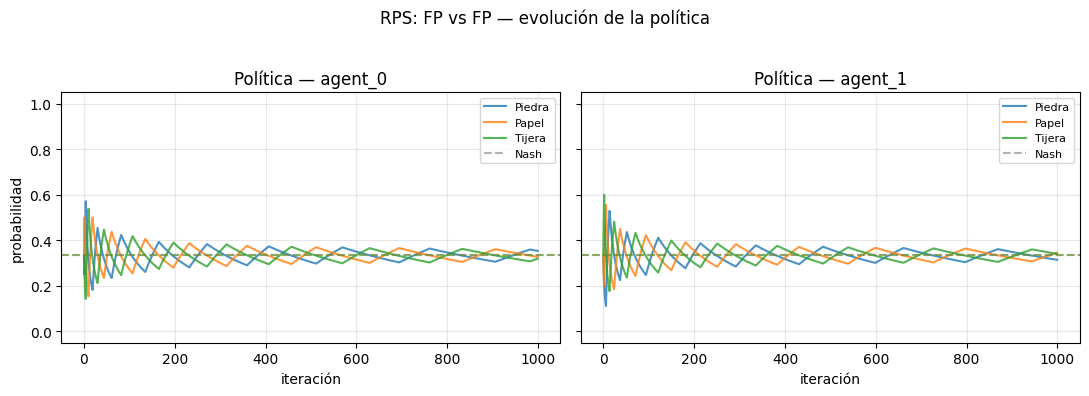

In [5]:
plot_policy_evolution(history_fp, action_labels=LABELS, nash=NASH,
                      title='RPS: FP vs FP — evolución de la política',
                      save='rps/policy_evolution_fp_vs_fp', max_iter=MAX_ITER)
plt.show()

### Distancia al Nash mixto

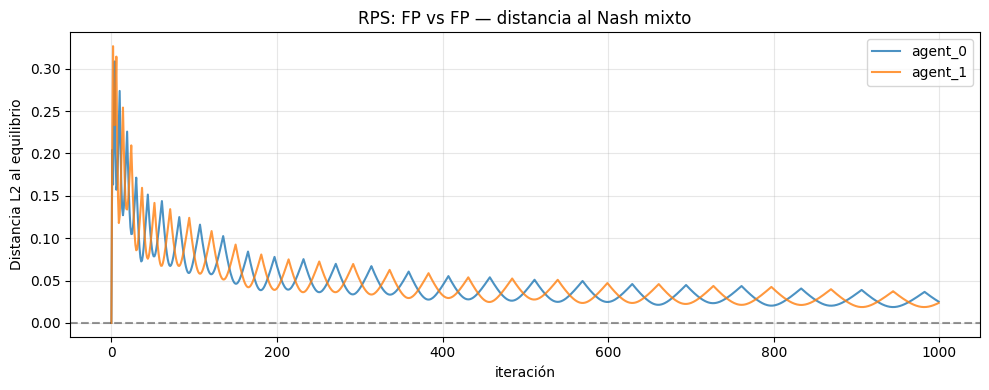

In [6]:
plot_distance_to_nash(history_fp, nash=NASH, max_iter=MAX_ITER,
                      title='RPS: FP vs FP — distancia al Nash mixto',
                      save='rps/distance_to_nash_fp_vs_fp')
plt.show()

### Reward promedio acumulado

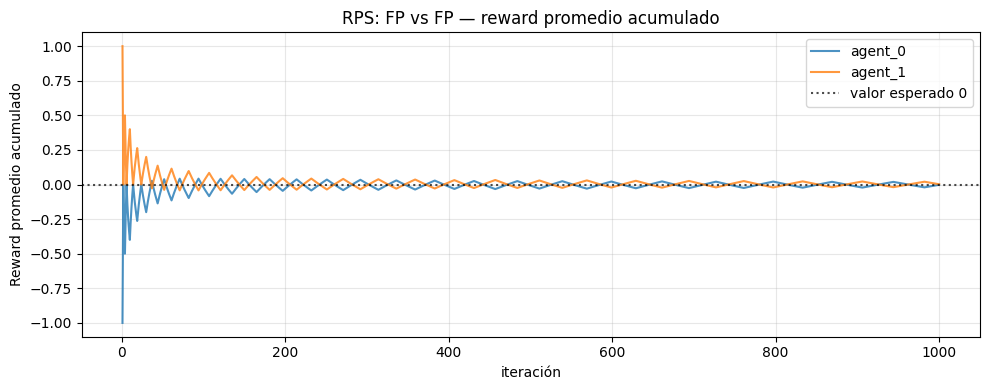

In [7]:
plot_cumulative_average_reward(history_fp, expected_value=0, max_iter=MAX_ITER,
                               title='RPS: FP vs FP — reward promedio acumulado',
                               save='rps/reward_cum_avg_fp_vs_fp')
plt.show()

### Trayectoria en el simplex

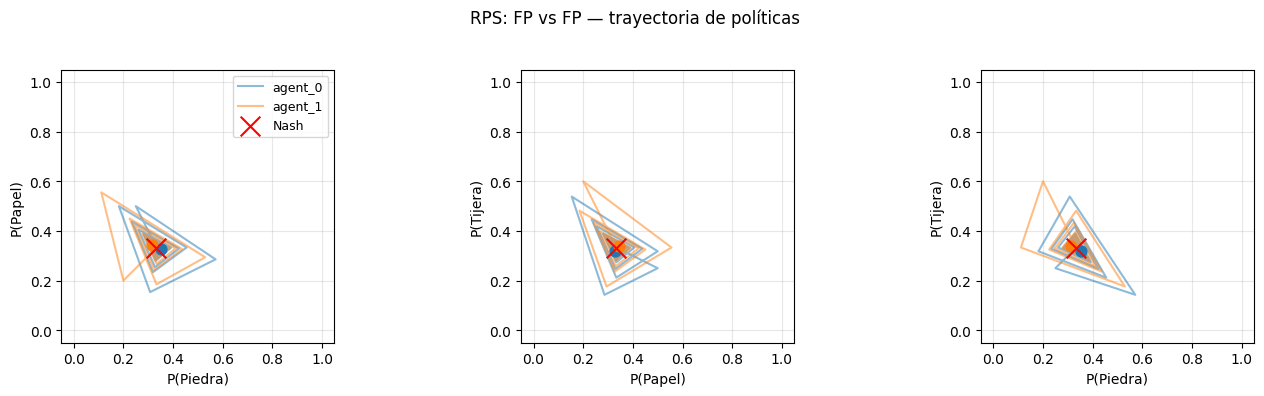

In [8]:
plot_simplex_pairs(history_fp['policy_history']['agent_0'],
                   history_fp['policy_history']['agent_1'],
                   nash=NASH, action_labels=LABELS,
                   title='RPS: FP vs FP — trayectoria de políticas',
                   save='rps/simplex_pairs_fp_vs_fp', max_iter=MAX_ITER)
plt.show()

## RegretMatching vs RegretMatching

En RM vs RM se observa la política promedio temporal (`learned_policy`). La política instantánea puede oscilar, pero el promedio debería aproximarse al equilibrio mixto uniforme.

In [9]:
log.info('RM vs RM en RPS — iniciando experimento')

agent_pair_rm = [(RegretMatching, {}), (RegretMatching, {})]
history_rm = exp.cached_run('rps_history_rm_vs_rm', RPS(), agent_pair_rm,
                            iterations=ITERATIONS, seed=1)

log.info(f'RM vs RM: política promedio final agent_0={history_rm["policy_history"]["agent_0"][-1].round(3)}, '
         f'agent_1={history_rm["policy_history"]["agent_1"][-1].round(3)}')

2026-05-24 09:08:13 | INFO    | RM vs RM en RPS — iniciando experimento
2026-05-24 09:08:14 | INFO    | RM vs RM: política promedio final agent_0=[0.331 0.345 0.324], agent_1=[0.322 0.331 0.348]


### Política promedio aprendida

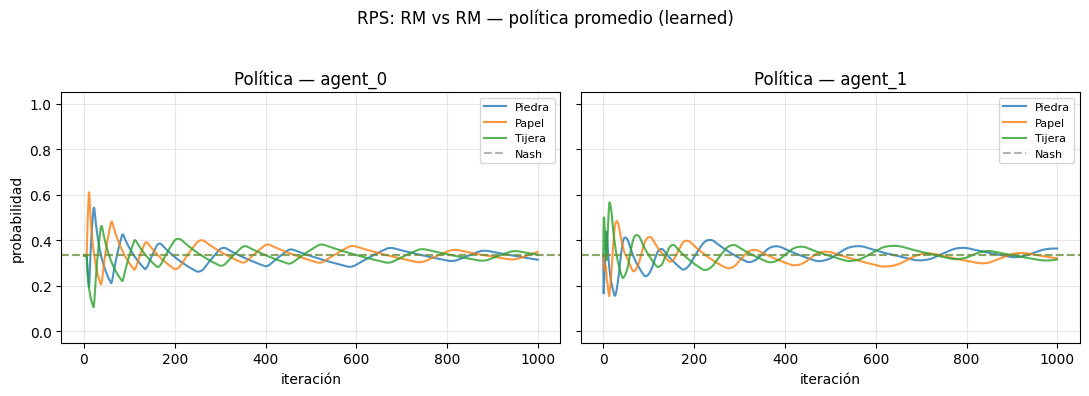

In [10]:
plot_policy_evolution(history_rm, action_labels=LABELS, nash=NASH,
                      title='RPS: RM vs RM — política promedio (learned)',
                      save='rps/policy_evolution_rm_vs_rm', max_iter=MAX_ITER)
plt.show()

### Distancia al equilibrio

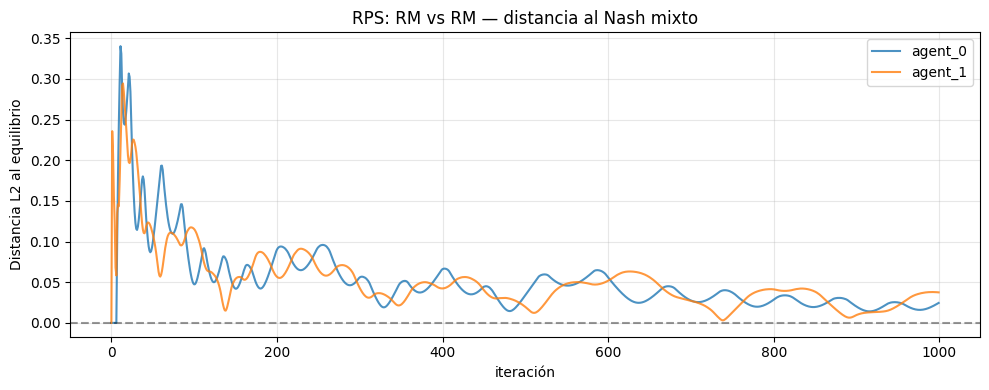

In [11]:
plot_distance_to_nash(history_rm, nash=NASH, max_iter=MAX_ITER,
                      title='RPS: RM vs RM — distancia al Nash mixto',
                      save='rps/distance_to_nash_rm_vs_rm')
plt.show()

### Reward promedio acumulado

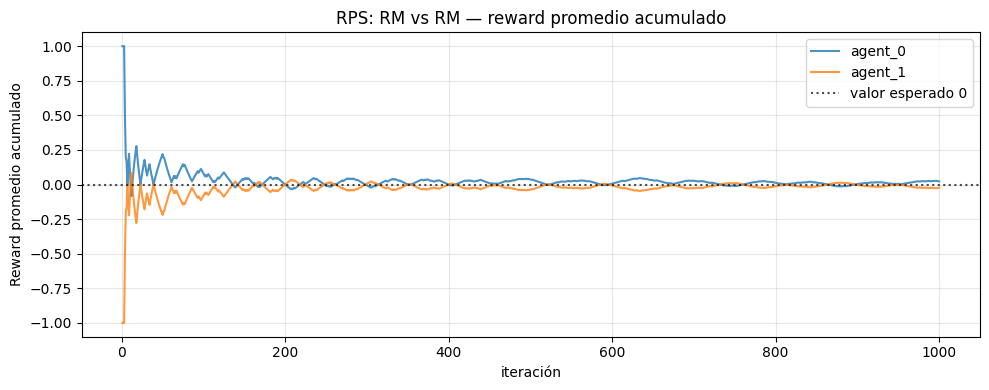

In [12]:
plot_cumulative_average_reward(history_rm, expected_value=0, max_iter=MAX_ITER,
                               title='RPS: RM vs RM — reward promedio acumulado',
                               save='rps/reward_cum_avg_rm_vs_rm')
plt.show()

### Regrets acumulados

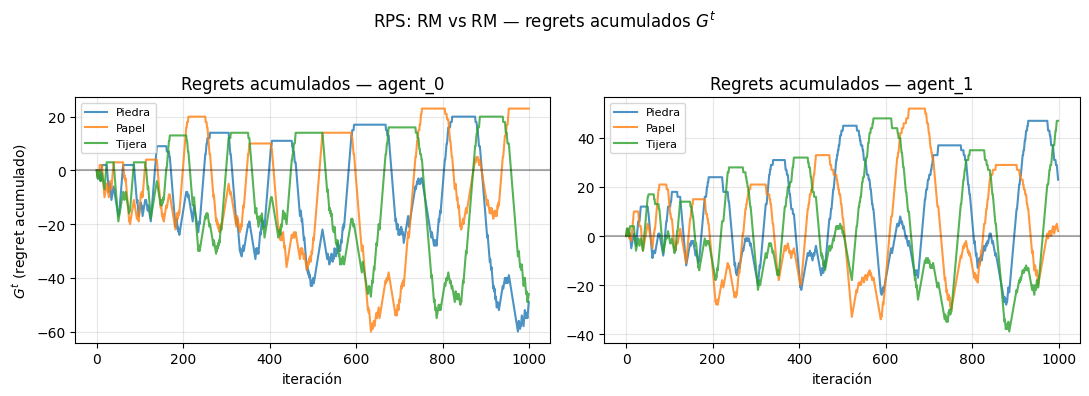

In [13]:
plot_cumulative_regret(history_rm, action_labels=LABELS,
                       title='RPS: RM vs RM — regrets acumulados $G^t$',
                       save='rps/cum_regrets_rm_vs_rm', max_iter=MAX_ITER)
plt.show()

### Regret promedio positivo / t

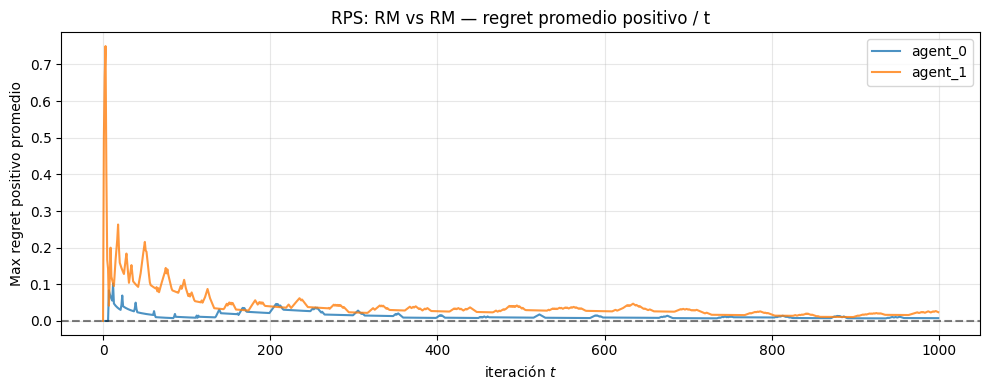

In [14]:
plot_average_positive_regret(history_rm,
                             title='RPS: RM vs RM — regret promedio positivo / t',
                             save='rps/avg_positive_regret_rm_vs_rm', max_iter=MAX_ITER)
plt.show()

### Trayectoria en el simplex

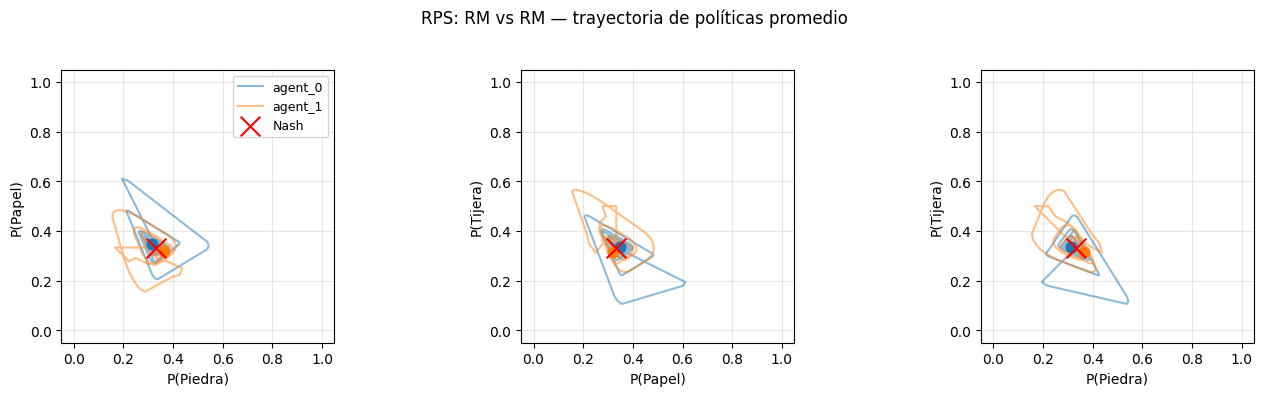

In [15]:
plot_simplex_pairs(history_rm['policy_history']['agent_0'],
                   history_rm['policy_history']['agent_1'],
                   nash=NASH, action_labels=LABELS,
                   title='RPS: RM vs RM — trayectoria de políticas promedio',
                   save='rps/simplex_pairs_rm_vs_rm', max_iter=MAX_ITER)
plt.show()

## FictitiousPlay vs RegretMatching

Este escenario mezcla una dinámica de mejor respuesta empírica (FP) con una dinámica no-regret (RM). Se espera aproximación al equilibrio mixto, aunque con trayectorias distintas.

In [16]:
log.info('FP vs RM en RPS — iniciando experimento')

fp_initial = {'agent_0': np.array([1, 1, 1]), 'agent_1': np.array([1, 1, 1])}
agent_pair_fp_rm = [
    (FictitiousPlay, {'initial': fp_initial}),
    (RegretMatching, {}),
]

history_fp_rm = exp.cached_run('rps_history_fp_vs_rm', RPS(), agent_pair_fp_rm,
                               iterations=ITERATIONS, seed=1)

log.info(f'FP vs RM: política final agent_0={history_fp_rm["policy_history"]["agent_0"][-1].round(3)}, '
         f'agent_1={history_fp_rm["policy_history"]["agent_1"][-1].round(3)}')

2026-05-24 09:08:15 | INFO    | FP vs RM en RPS — iniciando experimento
2026-05-24 09:08:16 | INFO    | FP vs RM: política final agent_0=[0.333 0.325 0.341], agent_1=[0.332 0.336 0.332]


### Políticas aprendidas (FP empírica + RM promedio)

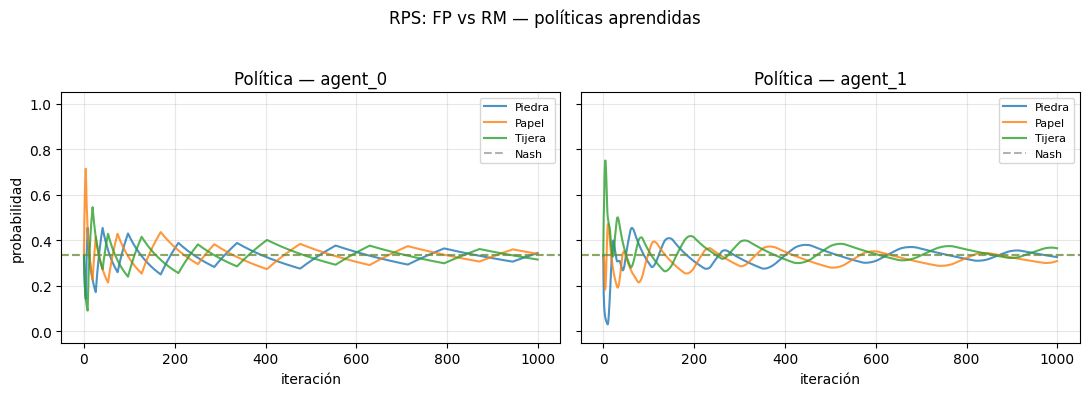

In [17]:
plot_policy_evolution(history_fp_rm, action_labels=LABELS, nash=NASH,
                      title='RPS: FP vs RM — políticas aprendidas',
                      save='rps/policy_evolution_fp_vs_rm', max_iter=MAX_ITER)
plt.show()

### Distancia al equilibrio + reward acumulado

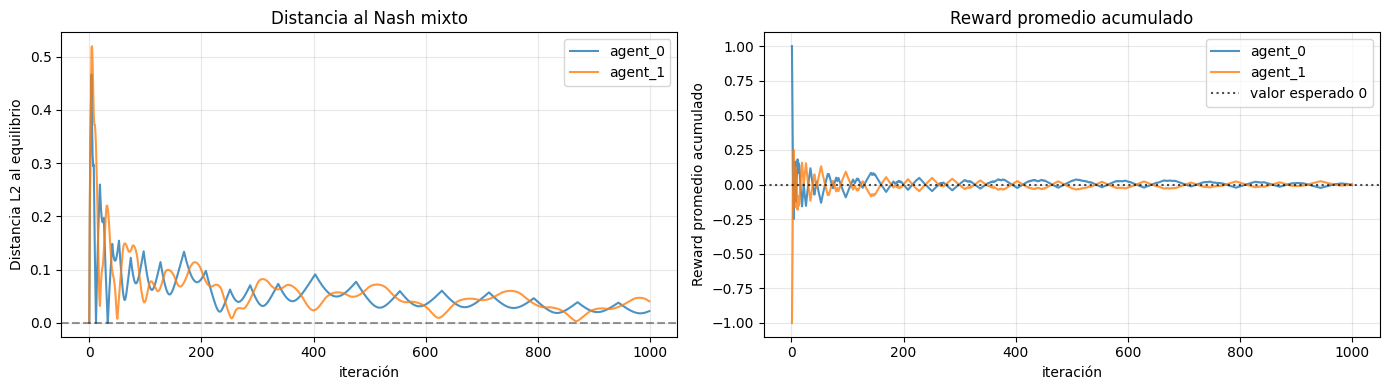

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_distance_to_nash(history_fp_rm, nash=NASH, max_iter=MAX_ITER,
                      ax=axes[0], title='Distancia al Nash mixto')
plot_cumulative_average_reward(history_fp_rm, expected_value=0, max_iter=MAX_ITER,
                               ax=axes[1], title='Reward promedio acumulado')
plt.tight_layout()
savefig('rps/distance_and_reward_fp_vs_rm')
plt.show()

### RM: política instantánea vs promedio temporal

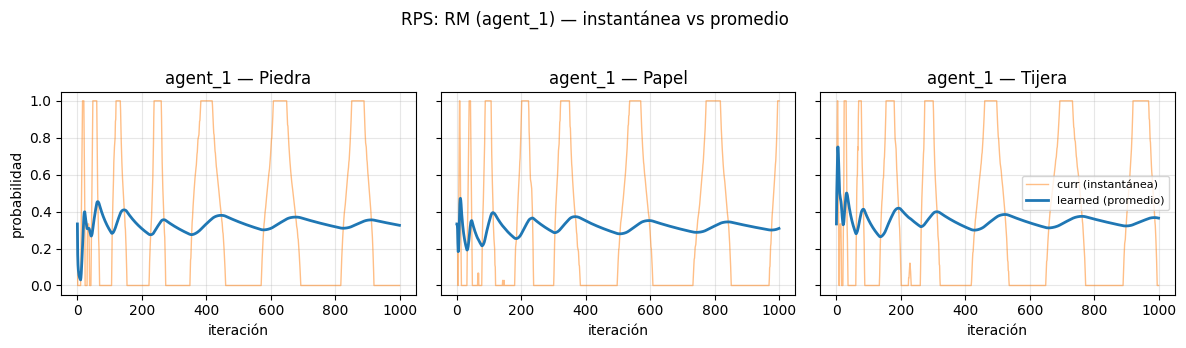

In [19]:
# Sólo aplica al agente RM (agent_1 en este pair)
plot_instantaneous_vs_average_policy(history_fp_rm, action_labels=LABELS,
                                     agent='agent_1',
                                     title='RPS: RM (agent_1) — instantánea vs promedio',
                                     save='rps/curr_vs_avg_policy_rm_in_fp_vs_rm',
                                     max_iter=MAX_ITER)
plt.show()

### Trayectoria en el simplex

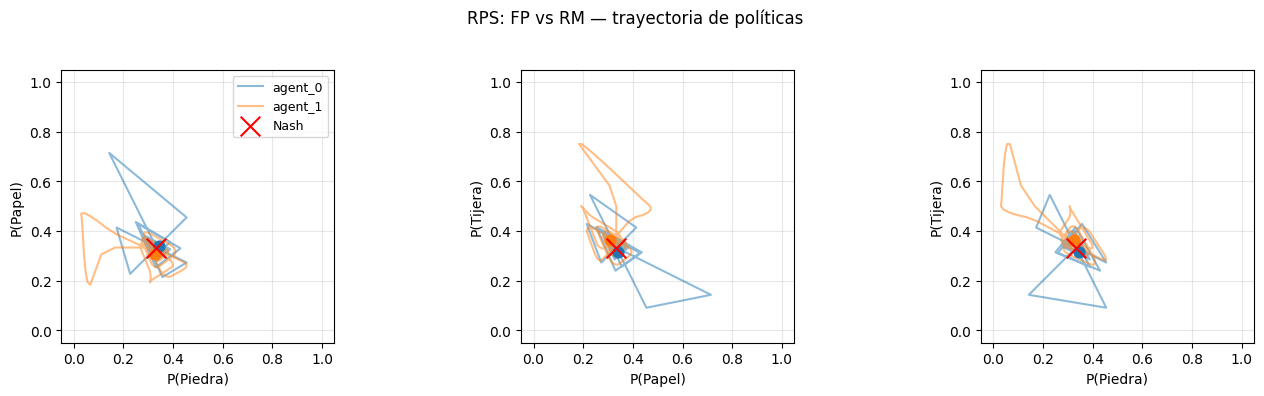

In [20]:
plot_simplex_pairs(history_fp_rm['policy_history']['agent_0'],
                   history_fp_rm['policy_history']['agent_1'],
                   nash=NASH, action_labels=LABELS,
                   title='RPS: FP vs RM — trayectoria de políticas',
                   save='rps/simplex_pairs_fp_vs_rm', max_iter=MAX_ITER)
plt.show()

## FictitiousPlay vs RandomAgent

In [3]:
log.info('FP vs Random en RPS - iniciando experimento')

fp_initial = {'agent_0': np.array([1, 1, 1]), 'agent_1': np.array([1, 1, 1])}
agent_pair_fp_random = [
    (FictitiousPlay, {'initial': fp_initial}),
    (RandomAgent, {}),
]

history_fp_random = exp.cached_run('rps_history_fp_vs_random', RPS(), agent_pair_fp_random,
                                   iterations=ITERATIONS, seed=1)

log.info(f'FP vs Random: politica final agent_0={history_fp_random["policy_history"]["agent_0"][-1].round(3)}, '
         f'agent_1={history_fp_random["policy_history"]["agent_1"][-1].round(3)}')

2026-05-24 19:50:36 | INFO    | FP vs Random en RPS - iniciando experimento
2026-05-24 19:50:36 | INFO    | FP vs Random: politica final agent_0=[0.    0.974 0.026], agent_1=[0.333 0.333 0.333]


### Politicas aprendidas

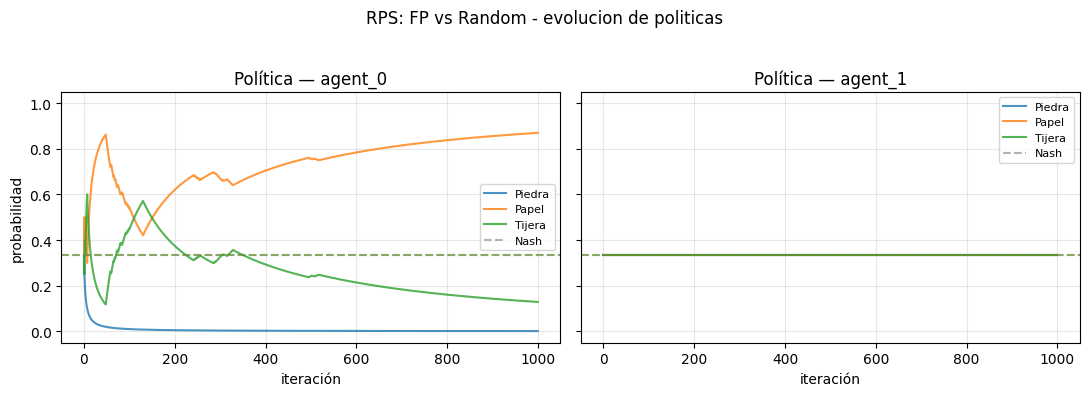

In [4]:
plot_policy_evolution(history_fp_random, action_labels=LABELS, nash=NASH,
                      title='RPS: FP vs Random - evolucion de politicas',
                      save='rps/policy_evolution_fp_vs_random', max_iter=MAX_ITER)
plt.show()

### Distancia al equilibrio + reward acumulado

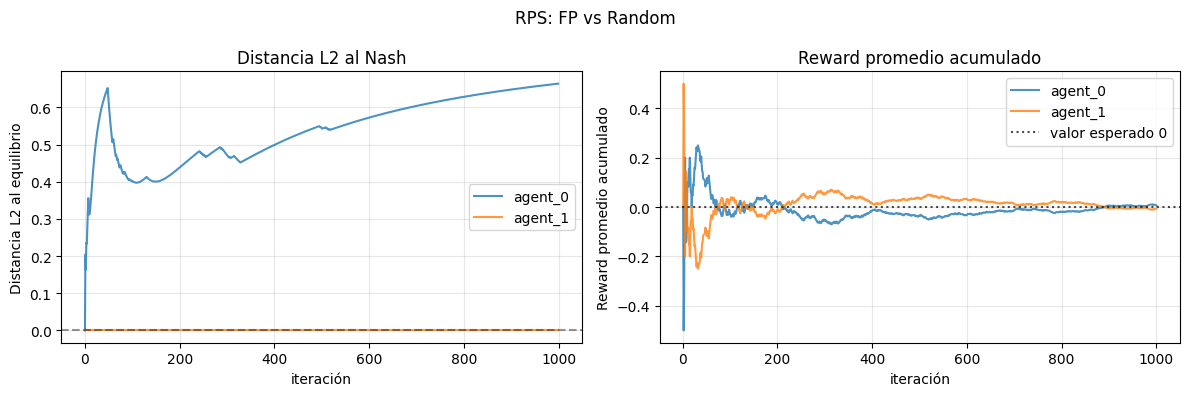

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_distance_to_nash(history_fp_random, nash=NASH, ax=axes[0], max_iter=MAX_ITER,
                      title='Distancia L2 al Nash')
plot_cumulative_average_reward(history_fp_random, expected_value=0, ax=axes[1],
                               max_iter=MAX_ITER, title='Reward promedio acumulado')
fig.suptitle('RPS: FP vs Random')
fig.tight_layout()
savefig('rps/distance_and_reward_fp_vs_random')
plt.show()

### Trayectoria en el simplex

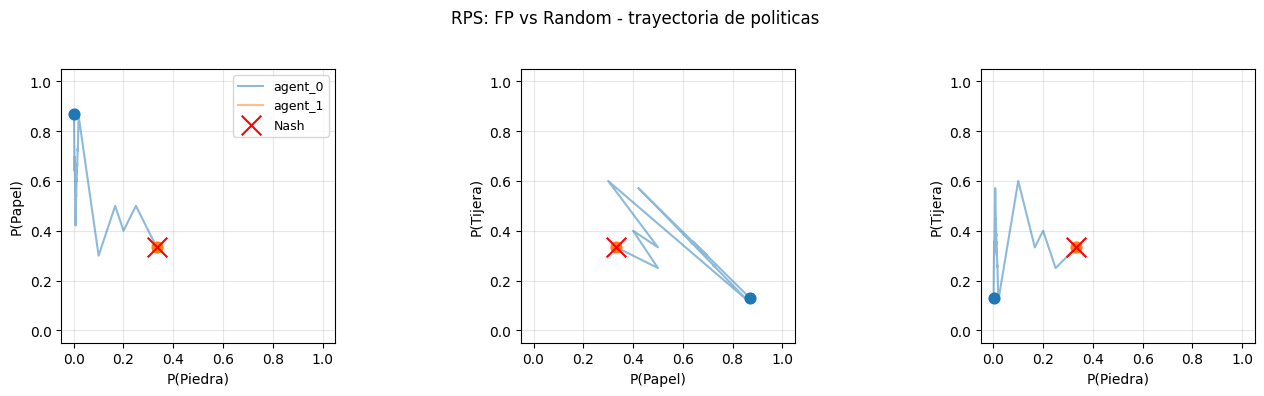

In [6]:
plot_simplex_pairs(history_fp_random['policy_history']['agent_0'],
                   history_fp_random['policy_history']['agent_1'],
                   nash=NASH, action_labels=LABELS,
                   title='RPS: FP vs Random - trayectoria de politicas',
                   save='rps/simplex_pairs_fp_vs_random', max_iter=MAX_ITER)
plt.show()

## RegretMatching vs RandomAgent

In [7]:
log.info('RM vs Random en RPS - iniciando experimento')

agent_pair_rm_random = [
    (RegretMatching, {}),
    (RandomAgent, {}),
]

history_rm_random = exp.cached_run('rps_history_rm_vs_random', RPS(), agent_pair_rm_random,
                                   iterations=ITERATIONS, seed=1)

log.info(f'RM vs Random: politica final agent_0={history_rm_random["policy_history"]["agent_0"][-1].round(3)}, '
         f'agent_1={history_rm_random["policy_history"]["agent_1"][-1].round(3)}')

2026-05-24 19:54:16 | INFO    | RM vs Random en RPS - iniciando experimento
2026-05-24 19:54:16 | INFO    | RM vs Random: politica final agent_0=[0.    0.948 0.052], agent_1=[0.333 0.333 0.333]


### Politica promedio aprendida

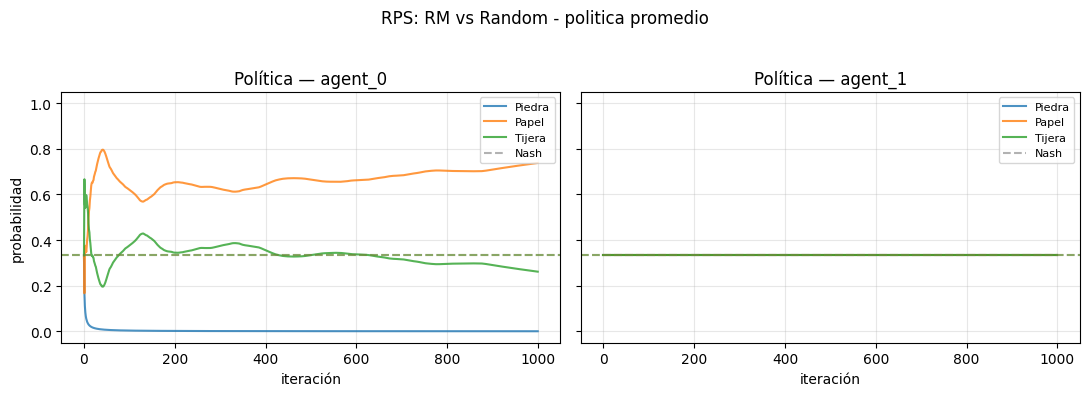

In [8]:
plot_policy_evolution(history_rm_random, action_labels=LABELS, nash=NASH,
                      title='RPS: RM vs Random - politica promedio',
                      save='rps/policy_evolution_rm_vs_random', max_iter=MAX_ITER)
plt.show()

### Distancia al equilibrio + reward acumulado

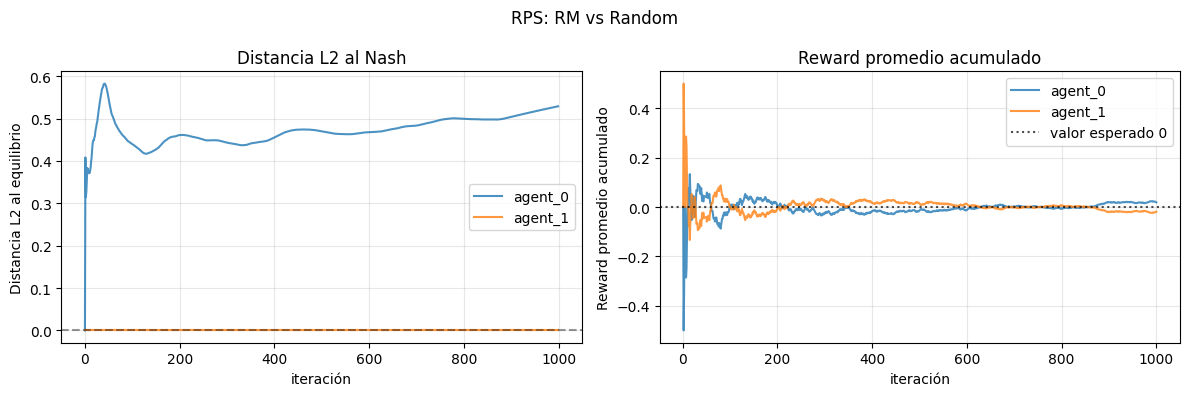

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_distance_to_nash(history_rm_random, nash=NASH, ax=axes[0], max_iter=MAX_ITER,
                      title='Distancia L2 al Nash')
plot_cumulative_average_reward(history_rm_random, expected_value=0, ax=axes[1],
                               max_iter=MAX_ITER, title='Reward promedio acumulado')
fig.suptitle('RPS: RM vs Random')
fig.tight_layout()
savefig('rps/distance_and_reward_rm_vs_random')
plt.show()

### Regrets acumulados

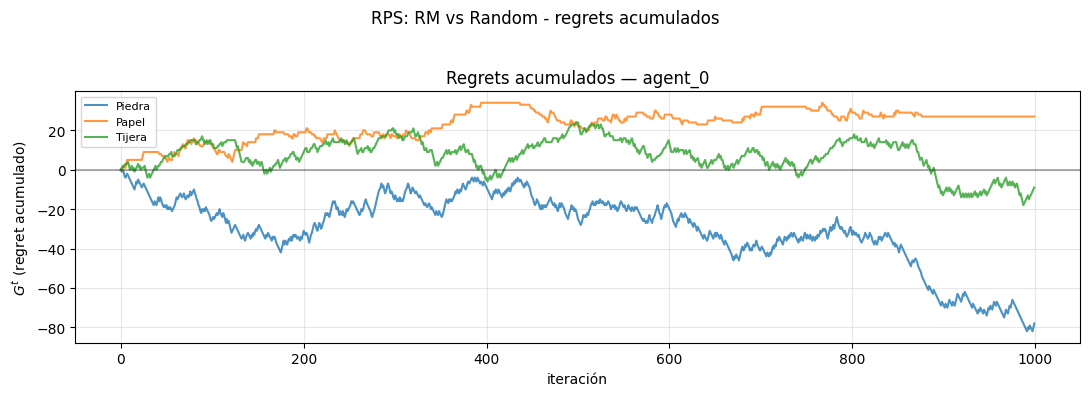

In [10]:
plot_cumulative_regret(history_rm_random, action_labels=LABELS,
                       title='RPS: RM vs Random - regrets acumulados',
                       save='rps/cum_regrets_rm_vs_random', max_iter=MAX_ITER)
plt.show()

### Regret promedio positivo / t

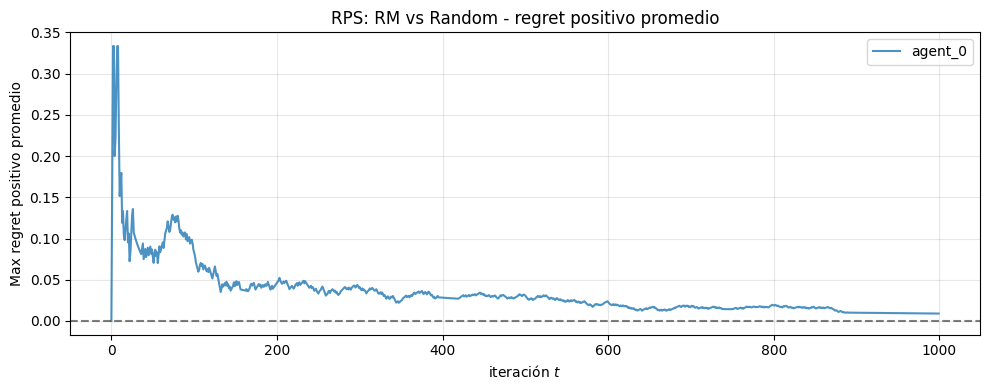

In [11]:
plot_average_positive_regret(history_rm_random,
                             title='RPS: RM vs Random - regret positivo promedio',
                             save='rps/avg_positive_regret_rm_vs_random', max_iter=MAX_ITER)
plt.show()

### RM: politica instantanea vs promedio temporal

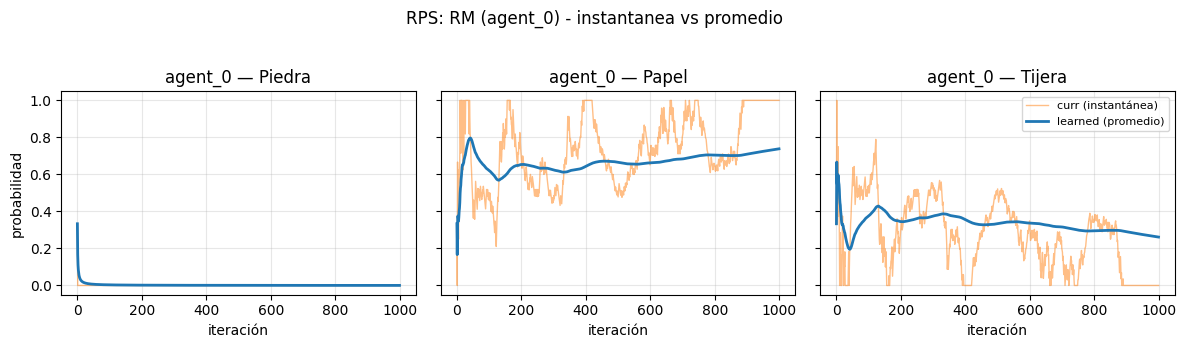

In [12]:
plot_instantaneous_vs_average_policy(history_rm_random, action_labels=LABELS,
                                     agent='agent_0',
                                     title='RPS: RM (agent_0) - instantanea vs promedio',
                                     save='rps/curr_vs_avg_policy_rm_in_rm_vs_random',
                                     max_iter=MAX_ITER)
plt.show()

### Trayectoria en el simplex

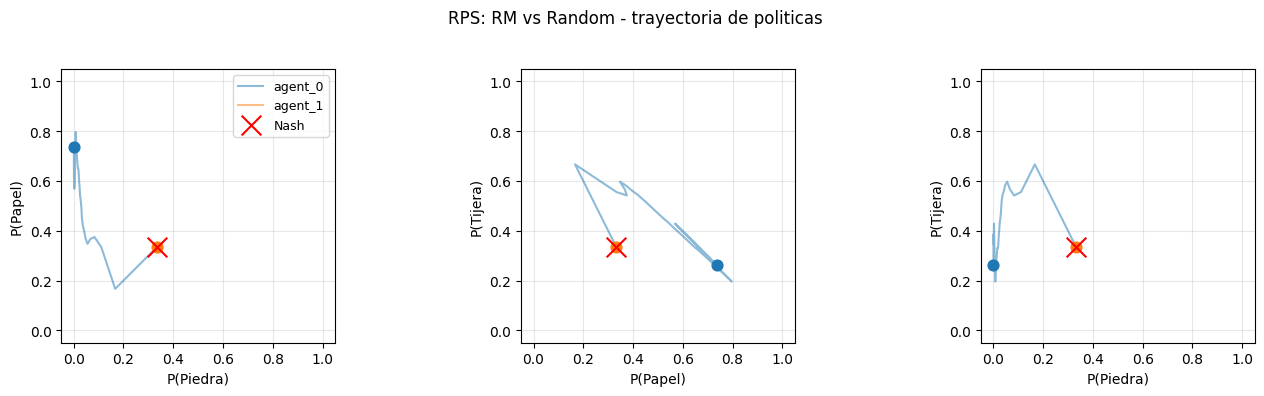

In [13]:
plot_simplex_pairs(history_rm_random['policy_history']['agent_0'],
                   history_rm_random['policy_history']['agent_1'],
                   nash=NASH, action_labels=LABELS,
                   title='RPS: RM vs Random - trayectoria de politicas',
                   save='rps/simplex_pairs_rm_vs_random', max_iter=MAX_ITER)
plt.show()

---

**Notas**:

- Los `history` dicts quedan persistidos en `data/rps/rps_history_*.pkl`. Por defecto `exp.cached_run` re-ejecuta y sobrescribe (`force=True`); pasar `force=False` para reutilizar el cache cuando el experimento no cambió.
- Las figuras se guardan en `images/rps/*.png`.
- El progreso del experimento queda en `logs/rps/RPS.log`.